In [1]:
import sax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

nm = 1e-3

Notas aclaratorias:

Hubo unos errores al momento de definir las longitudes, a pesar de que no coinciden con las del artículo, el WDM implementado con los MZI sigue funcionando de manera apropiada

### Simplified Dispersive Waveguide Model

This waveguide model incorporates the previously extracted effective index and group index values in order to approximate the first-order spectral dependence of the propagation constant.

The phase evolution is computed from a wavelength-dependent effective index approximation:

\begin{equation}
n_{\mathrm{eff}}(\lambda)
\end{equation}

while propagation losses are included through a simplified exponential attenuation term.

In [2]:
def waveguide(wl=1.55, length=10.0, wl0=1.55, ng=4.28, neff=2.38, loss=0.0) -> sax.SDict:
    dwl = wl - wl0
    dneff_dwl = (ng - neff) / wl0
    neff = neff - dwl * dneff_dwl
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase)
    
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict

### Simplified Directional Coupler Model

This model represents an ideal reciprocal directional coupler using a scattering matrix formalism.

Only coherent power splitting/combining and phase mixing between optical signals are considered.  
The model neglects several non-ideal effects, including:

- Excess loss
- Wavelength dependence
- Fabrication-induced asymmetries
- Bend and taper effects
- Geometrical corrections
- Propagation losses

Therefore, this representation should be interpreted as a first-order compact model intended for preliminary circuit-level simulations.  
Additional corrections may be required for fabrication-aware or layout-dependent analysis.

In [3]:
def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): 1j * kappa,
            ("in1", "out0"): 1j * kappa,
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

### Bloques de diseño

#### Bloque S1

In [4]:
S1, info = sax.circuit(
    netlist={
        "instances": {
            "InDC": "coupler",
            "ATop": "waveguide",
            "ABtm": "waveguide",
            "ACoup": "coupler",
            "BTop": "waveguide",
            "BBtm": "waveguide",
            "BCoup": "coupler",
            "CTop": "waveguide",
            "CBtm": "waveguide",
            "OutDC": "coupler",
        },
        "connections": {
            "InDC,out0": "ABtm,in0",
            "ABtm,out0": "ACoup,in0",
            "InDC,out1": "ATop,in0",
            "ATop,out0": "ACoup,in1",
        # -------------------------
            "ACoup,out0": "BBtm,in0",
            "BBtm,out0": "BCoup,in0",
            "ACoup,out1": "BTop,in0",
            "BTop,out0": "BCoup,in1",
        # -------------------------
            "BCoup,out0": "CBtm,in0",
            "CBtm,out0": "OutDC,in0",
            "BCoup,out1": "CTop,in0",
            "CTop,out0": "OutDC,in1",
        },
        "ports": {
            "in0": "InDC,in0",
            "in1": "InDC,in1",
            "out0": "OutDC,out0",
            "out1": "OutDC,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


#### Bloque S2

In [5]:
S2, info = sax.circuit(
    netlist={
        "instances": {
            "InDC": "coupler",
            "ATop": "waveguide",
            "ABtm": "waveguide",
            "ACoup": "coupler",
            "BTop": "waveguide",
            "BBtm": "waveguide",
            "OutDC": "coupler",
        },
        "connections": {
            "InDC,out0": "ABtm,in0",
            "ABtm,out0": "ACoup,in0",
            "InDC,out1": "ATop,in0",
            "ATop,out0": "ACoup,in1",
        # -------------------------
            "ACoup,out0": "BBtm,in0",
            "BBtm,out0": "OutDC,in0",
            "ACoup,out1": "BTop,in0",
            "BTop,out0": "OutDC,in1",
        },
        "ports": {
            "in0": "InDC,in0",
            "in1": "InDC,in1",
            "out0": "OutDC,out0",
            "out1": "OutDC,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

#### Parametros de simulación


In [6]:
wl0 = 1.55
neff = 2.38
ng = 4.28

# Diferencias de longitud para FSR de 40nm y 80nm
dL_S1 = (wl0**2) / (ng * 0.040)
dL_S2 = (wl0**2) / (ng * 0.080)

# Lpi de ajuste
Lpi = wl0 / (2 * neff)
Lpi_05 = 0.5 * Lpi

L1 = 23.250 # Se menciona en el articulo que este es el valor de L1 para una guia de 450 nm de grosor
L2_S1 = L1 - dL_S1
L2_S2 = L1 - dL_S2

In [7]:
print(f"Lpi: {Lpi:.3f} um")
print(f"L1: {L1:.3f} um")
print(f"L2_S1: {L2_S1:.3f} um")
print(f"L2_S2: {L2_S2:.3f} um")

Lpi: 0.326 um
L1: 23.250 um
L2_S1: 9.217 um
L2_S2: 16.233 um


In [8]:
wl = jnp.linspace(1.50, 1.60, 1000)

_S1 = S1(wl=wl,
       InDC = {"coupling":0.5},
       ACoup = {"coupling":0.17},
       BCoup = {"coupling":0.23},
       OutDC = {"coupling":0.05},

       ATop = {"wl":wl, "length": L1},
       ABtm = {"wl":wl, "length": L2_S1},

       BTop = {"wl":wl, "length": 2 * L2_S1},
       BBtm = {"wl":wl, "length": 2 * L1},

       CTop = {"wl":wl, "length": 2 * L2_S1},
       CBtm = {"wl":wl, "length": 2 * L1 + Lpi} 
       )

_S2 = S2(wl=wl,
       InDC = {"coupling":0.5},
       ACoup = {"coupling":0.3},
       OutDC = {"coupling":0.05},

       ATop = {"wl":wl, "length": L1},
       ABtm = {"wl":wl, "length": L2_S2},

       BTop = {"wl":wl, "length": 2 * L2_S2},
       BBtm = {"wl":wl, "length": 2 * L1},

       )

_S2_mod = S2(wl=wl,
       InDC = {"coupling":0.5},
       ACoup = {"coupling":0.3},
       OutDC = {"coupling":0.05},

       ATop = {"wl":wl, "length": L1 + Lpi_05},
       ABtm = {"wl":wl, "length": L2_S2},

       BTop = {"wl":wl, "length": 2 * L2_S2},
       BBtm = {"wl":wl, "length": 2 * (L1 + Lpi_05)},

       )

### Pruebas de los bloques

#### Salidas de la primera etapa

<figure> 
    <center>
        <img src="img/test.png" style="width:60%">
        <figcaption align = "center"> <i> <b> Fig. 1. </b> Bloque de prueba AS1In </i> </figcaption>
    </center>
</figure>

In [9]:
TCross_S1 = 10 * np.log10(np.abs(_S1[('in1', 'out0')])**2)
TBar_S1 = 10 * np.log10(np.abs(_S1[('in1', 'out1')])**2)

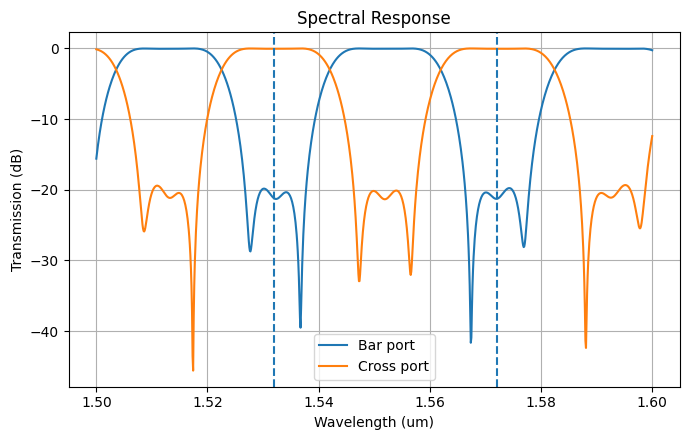

In [11]:
lambda1 = 1.532
lambda2 = lambda1 + 40 * nm

plt.figure(figsize=(7,4.5))

plt.plot(wl, TBar_S1, label='Bar port')
plt.plot(wl, TCross_S1, label='Cross port')

plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (dB)")
plt.axvline(lambda1, linestyle='--')
plt.axvline(lambda2, linestyle='--')

plt.title("Spectral Response")
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

#### Salidas de la segunda etapa

<figure> 
    <center>
        <img src="img/OutsStage2.png" style="width:60%">
        <figcaption align = "center"> <i> <b> Fig. 1. </b> Salidas de la segunda etapa </i> </figcaption>
    </center>
</figure>

In [12]:
MUX_Stage_2, info = sax.circuit(
    netlist={
        "instances": {
            # Stage 1
            "AS1In": "_S1",
            # Stage 2
            "BS1Top": "_S1",
            "BS1Btm": "_S1",
        },
        "connections": {
            # Stage 1
            "AS1In,out0": "BS1Top,in1",
            "AS1In,out1": "BS1Btm,in1",            
        },
        "ports": {
            "in0": "AS1In,in0",
            "in1": "AS1In,in1",    
            "out0": "BS1Top,out0",
            "out1": "BS1Btm,out1"
    },
    },
    models={
        "_S1": lambda **kwargs: _S1,
    }
)

In [13]:
S = MUX_Stage_2()

TCross_BS1Top = 10 * np.log10(np.abs(S[('in1', 'out0')])**2)
TBar_BS1Btm = 10 * np.log10(np.abs(S[('in1', 'out1')])**2)

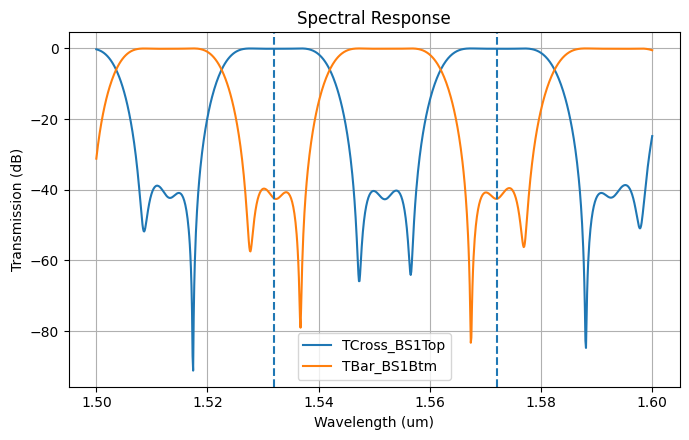

In [14]:
plt.figure(figsize=(7,4.5))

plt.plot(wl, TCross_BS1Top, label='TCross_BS1Top')
plt.plot(wl, TBar_BS1Btm, label='TBar_BS1Btm')

plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (dB)")
plt.axvline(lambda1, linestyle='--')
plt.axvline(lambda2, linestyle='--')

plt.title("Spectral Response")
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

#### Salidas de la tercera etapa

<figure> 
    <center>
        <img src="img/OutsStage3.png" style="width:60%">
        <figcaption align = "center"> <i> <b> Fig. 1. </b> Salidas de la segunda etapa </i> </figcaption>
    </center>
</figure>

In [15]:
TCross_S2 = 10 * np.log10(np.abs(_S2[('in1', 'out0')])**2)
TBar_S2 = 10 * np.log10(np.abs(_S2[('in1', 'out1')])**2)

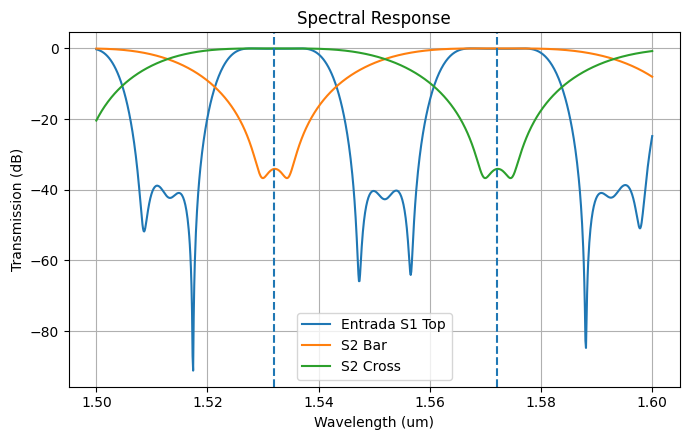

In [16]:
lambda1 = 1.532
lambda2 = lambda1 + 40 * nm

plt.figure(figsize=(7,4.5))

plt.plot(wl, TCross_BS1Top, label='Entrada S1 Top')


plt.plot(wl, TBar_S2, label='S2 Bar')
plt.plot(wl, TCross_S2, label='S2 Cross')

plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (dB)")
plt.axvline(lambda1, linestyle='--')
plt.axvline(lambda2, linestyle='--')

plt.title("Spectral Response")
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

In [17]:
TCross_S2_mod = 10 * np.log10(np.abs(_S2_mod[('in1', 'out0')])**2)
TBar_S2_mod = 10 * np.log10(np.abs(_S2_mod[('in1', 'out1')])**2)

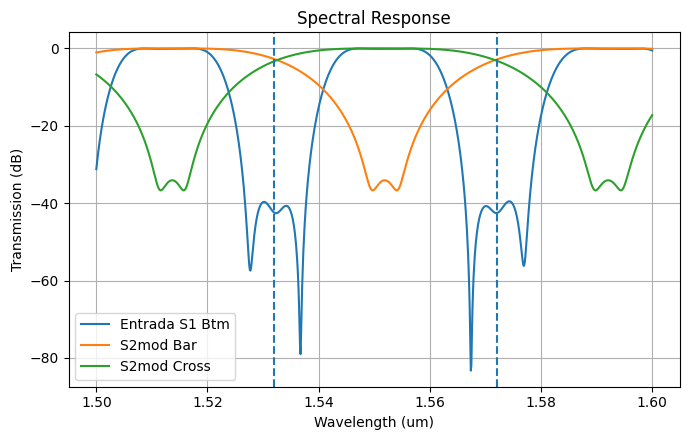

In [18]:
TCross_S2_mod = 10 * np.log10(np.abs(_S2_mod[('in1', 'out0')])**2)
TBar_S2_mod = 10 * np.log10(np.abs(_S2_mod[('in1', 'out1')])**2)


lambda1 = 1.532
lambda2 = lambda1 + 40 * nm

plt.figure(figsize=(7,4.5))

plt.plot(wl, TBar_BS1Btm, label='Entrada S1 Btm')


plt.plot(wl, TBar_S2_mod, label='S2mod Bar')
plt.plot(wl, TCross_S2_mod, label='S2mod Cross')

plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (dB)")
plt.axvline(lambda1, linestyle='--')
plt.axvline(lambda2, linestyle='--')

plt.title("Spectral Response")
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

Una vez se conoce que la respuesta de todos los MZI se encuentra alineada de manera que permiten la formación de los canales deseados, se procede a la construcción del WDM

## WDM simulation

<figure> 
    <center>
        <img src="img/MUXDesign.png" style="width:60%">
    </center>
</figure>


In [24]:
MUX, info = sax.circuit(
    netlist={
        "instances": {
            # Stage 1
            "AS1In": "_S1",
            # Stage 2
            "BS1Top": "_S1",
            "BS1Btm": "_S1",
            # Stage 3
            "CS2Top": "_S2",
            "CS2Btm": "_S2_mod",
            # Stage 4
            "DS2Out1": "_S2",
            "DS2Out2": "_S2",
            "DS2Out3": "_S2_mod",
            "DS2Out4": "_S2_mod",
        },
        "connections": {
            # Stage 1
            "AS1In,out0": "BS1Top,in1",
            "AS1In,out1": "BS1Btm,in1",
            
            # Stage 2
            "BS1Top,out0": "CS2Top,in1",
            "BS1Btm,out1": "CS2Btm,in0",

            # Stage 3

            "CS2Top,out0": "DS2Out1,in1",
            "CS2Top,out1": "DS2Out2,in0",
            "CS2Btm,out0": "DS2Out3,in1",
            "CS2Btm,out1": "DS2Out4,in0",

            
        },
        "ports": {
            "in0": "AS1In,in0",
            "in1": "AS1In,in1",    
            "out1530": "DS2Out1,out0",
            "out1570": "DS2Out2,out0",
            "out1510": "DS2Out3,out1",
            "out1550": "DS2Out4,out1",
    },
    },
    models={
        "_S1": lambda **kwargs: _S1,
        "_S2": lambda **kwargs: _S2,
        "_S2_mod": lambda **kwargs: _S2_mod
    }
)

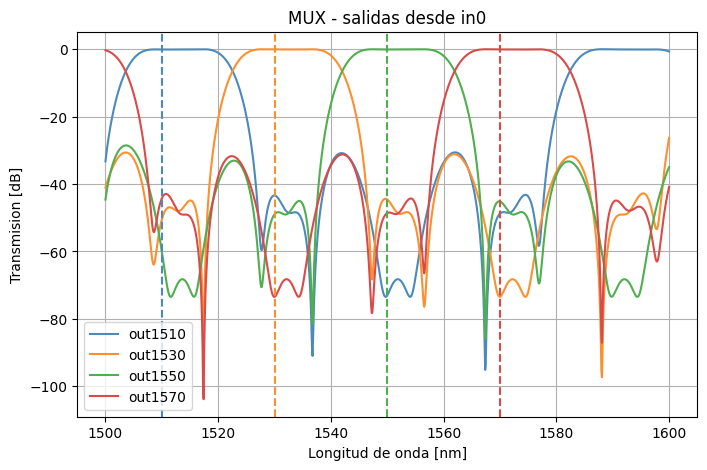

In [28]:
S = MUX()
plt.figure(figsize=(8, 5))

plt.plot(wl * 1000, 10*np.log10(np.abs(S[("in1", "out1510")])**2), color="#4c8abb", label="out1510")
plt.plot(wl * 1000, 10*np.log10(np.abs(S[("in1", "out1530")])**2), color="#fe8f2d", label="out1530")
plt.plot(wl * 1000, 10*np.log10(np.abs(S[("in1", "out1550")])**2), color="#4fae4e", label="out1550")
plt.plot(wl * 1000, 10*np.log10(np.abs(S[("in1", "out1570")])**2), color="#da4a49", label="out1570")

plt.axvline(1510, color="#4c8abb", linestyle='--')
plt.axvline(1530, color="#fe8f2d", linestyle='--')
plt.axvline(1550, color="#4fae4e", linestyle='--')
plt.axvline(1570, color="#da4a49", linestyle='--')

plt.xlabel("Longitud de onda [nm]")
plt.ylabel("Transmision [dB]")
plt.title("MUX - salidas desde in0")
plt.grid(True)
plt.legend()
plt.show()